# Gaussian Naive Bayes on the Breast Cancer Dataset

This notebook demonstrates the `GaussianNaiveBayes` classifier implemented in the `jiayi_ml` package.

The goal is to classify breast tumor samples as malignant or benign using numeric features derived from digitized images of breast mass cell nuclei.

This example emphasizes:

1. Probabilistic classification.
2. Class-conditional Gaussian assumptions.
3. The Naive Bayes conditional independence assumption.
4. Binary classification evaluation.
5. Confusion matrix interpretation.
6. False positive and false negative analysis.
7. Limitations of probabilistic assumptions in biomedical-style data.


## 1. Problem Statement

The Breast Cancer Wisconsin dataset is a binary classification dataset.

Each observation describes a tumor sample using numeric features computed from cell nuclei. The original target labels are:

- malignant
- benign

For this notebook, the target is recoded so that:

- `1` = malignant
- `0` = benign

This makes malignant tumors the positive class.

The prediction task is:

> Given numeric tumor measurements, predict whether the tumor is malignant or benign.

This is a supervised binary classification task.

Gaussian Naive Bayes is a useful model for this example because it produces class probabilities and has a clear probabilistic interpretation. However, its assumptions are strong, especially the assumption that features are conditionally independent given the class label.

This notebook is an educational machine learning example. It should not be interpreted as a clinical diagnostic tool.


## Modeling Hypothesis

Because several Breast Cancer features differ strongly between malignant and benign samples, Gaussian Naive Bayes should provide a useful probabilistic baseline.

The main hypothesis is:

> Gaussian Naive Bayes will classify many samples correctly because class-conditional feature distributions contain strong signal.

However, the independence assumption is likely unrealistic because many features are correlated measurements derived from related cell nucleus characteristics. Therefore, Naive Bayes should be interpreted as a simple baseline rather than a fully realistic data-generating model.


In [1]:
from pathlib import Path
import sys

# Make the local package importable whether the notebook is run from the
# project root or from inside the examples directory.
current_path = Path.cwd().resolve()
for candidate in [current_path, *current_path.parents]:
    if (candidate / "src" / "jiayi_ml").exists():
        sys.path.insert(0, str(candidate / "src"))
        PROJECT_ROOT = candidate
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

from jiayi_ml.preprocessing import StandardScaler
from jiayi_ml.supervised import GaussianNaiveBayes
from jiayi_ml.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

np.random.seed(438)
pd.set_option("display.precision", 4)


## 2. Load the Dataset

The dataset is loaded from `sklearn.datasets.load_breast_cancer`, so this notebook is reproducible without external downloads.

The original sklearn target encoding is:

- `0` = malignant
- `1` = benign

This notebook recodes the target so that malignant is the positive class.


In [2]:
data = load_breast_cancer(as_frame=True)

X = data.data
y_original = data.target
feature_names = X.columns.tolist()
target_names = data.target_names

# Recode target:
# original 0 = malignant, original 1 = benign
# new 1 = malignant, new 0 = benign
y = (y_original == 0).astype(int)

df = X.copy()
df["malignant"] = y

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Original target names:", target_names)
print("Number of features:", len(feature_names))

df.head()


Feature matrix shape: (569, 30)
Target shape: (569,)
Original target names: ['malignant' 'benign']
Number of features: 30


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,malignant
0,17.99,10.38,122.80,1001.0,0.1184,0.2776,0.3001,0.1471,0.2419,0.0787,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,1
1,20.57,17.77,132.90,1326.0,0.0847,0.0786,0.0869,0.0702,0.1812,0.0567,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.0890,1
2,19.69,21.25,130.00,1203.0,0.1096,0.1599,0.1974,0.1279,0.2069,0.0600,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.0876,1
3,11.42,20.38,77.58,386.1,0.1425,0.2839,0.2414,0.1052,0.2597,0.0974,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730,1
4,20.29,14.34,135.10,1297.0,0.1003,0.1328,0.1980,0.1043,0.1809,0.0588,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.0768,1


## 3. Exploratory Data Analysis

Before fitting a probabilistic classifier, we inspect:

- Missing values
- Class distribution
- Feature summaries
- Feature relationships with the target
- Feature correlations

This is important because Gaussian Naive Bayes makes assumptions about feature distributions and feature independence.


In [3]:
missing_values = df.isna().sum()

print("Total missing values:", int(missing_values.sum()))

summary = X.describe().T
summary.head(10)


Total missing values: 0


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.1273,3.5240,6.9810,11.7000,13.3700,15.7800,28.1100
mean texture,569.0,19.2896,4.3010,9.7100,16.1700,18.8400,21.8000,39.2800
mean perimeter,569.0,91.9690,24.2990,43.7900,75.1700,86.2400,104.1000,188.5000
mean area,569.0,654.8891,351.9141,143.5000,420.3000,551.1000,782.7000,2501.0000
mean smoothness,569.0,0.0964,0.0141,0.0526,0.0864,0.0959,0.1053,0.1634
mean compactness,569.0,0.1043,0.0528,0.0194,0.0649,0.0926,0.1304,0.3454
mean concavity,569.0,0.0888,0.0797,0.0000,0.0296,0.0615,0.1307,0.4268
mean concave points,569.0,0.0489,0.0388,0.0000,0.0203,0.0335,0.0740,0.2012
mean symmetry,569.0,0.1812,0.0274,0.1060,0.1619,0.1792,0.1957,0.3040
mean fractal dimension,569.0,0.0628,0.0071,0.0500,0.0577,0.0615,0.0661,0.0974


In [4]:
class_counts = pd.Series(y).value_counts().sort_index()
class_counts.index = ["benign (0)", "malignant (1)"]

class_counts_df = class_counts.to_frame(name="count")
class_counts_df["proportion"] = class_counts_df["count"] / class_counts_df["count"].sum()
class_counts_df


,count,proportion
benign (0),357,0.6274
malignant (1),212,0.3726


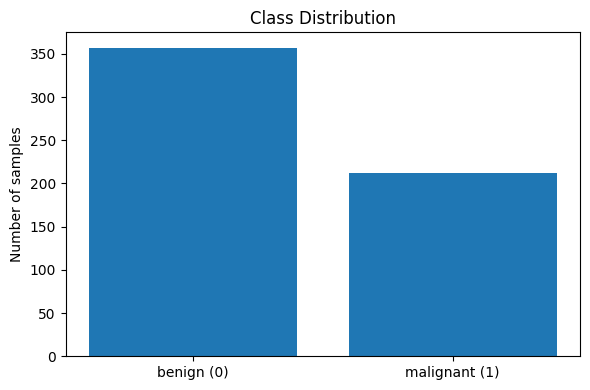

In [5]:
plt.figure(figsize=(6, 4))
plt.bar(class_counts_df.index, class_counts_df["count"])
plt.ylabel("Number of samples")
plt.title("Class Distribution")
plt.tight_layout()
plt.show()


The classes are not perfectly balanced. Because malignant is the positive class, evaluation should include precision, recall, F1 score, and a confusion matrix rather than accuracy alone.


In [6]:
correlations = df.corr(numeric_only=True)["malignant"].drop("malignant")
top_correlations = correlations.reindex(
    correlations.abs().sort_values(ascending=False).index
).head(12)

top_correlations_df = top_correlations.to_frame(name="correlation_with_malignant")
top_correlations_df


,correlation_with_malignant
worst concave points,0.7936
worst perimeter,0.7829
mean concave points,0.7766
worst radius,0.7765
mean perimeter,0.7426
worst area,0.7338
mean radius,0.7300
mean area,0.7090
mean concavity,0.6964
worst concavity,0.6596


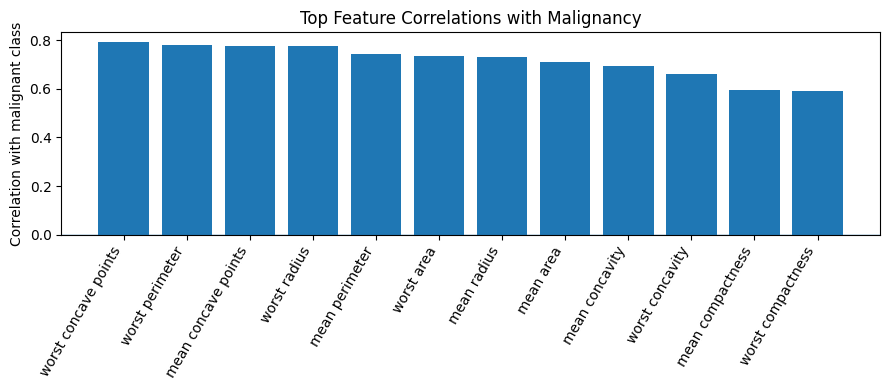

In [7]:
plt.figure(figsize=(9, 4))
plt.bar(top_correlations.index, top_correlations.values)
plt.axhline(0, linewidth=1)
plt.xticks(rotation=60, ha="right")
plt.ylabel("Correlation with malignant class")
plt.title("Top Feature Correlations with Malignancy")
plt.tight_layout()
plt.show()


The correlation analysis identifies features that are strongly associated with the malignant class. This does not imply causality, but it helps us understand which variables may be informative for classification.


## 4. Checking Distributional and Independence Assumptions

Gaussian Naive Bayes assumes that, within each class, each feature follows a Gaussian distribution. It also assumes that features are conditionally independent given the class.

The following plots inspect selected high-correlation features by class. The distributions do not need to be perfectly Gaussian for the model to be useful, but strong departures from the assumptions should be acknowledged.


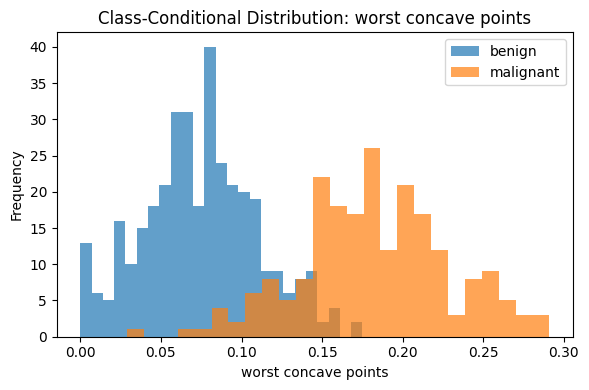

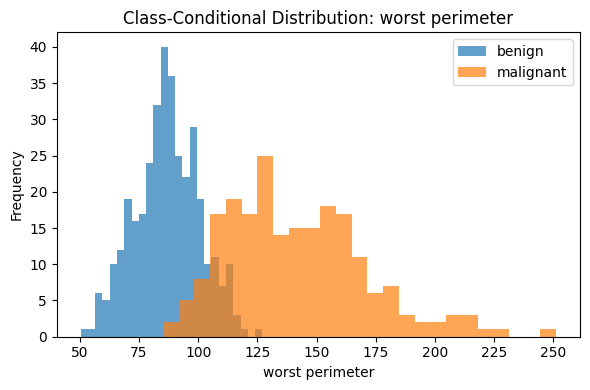

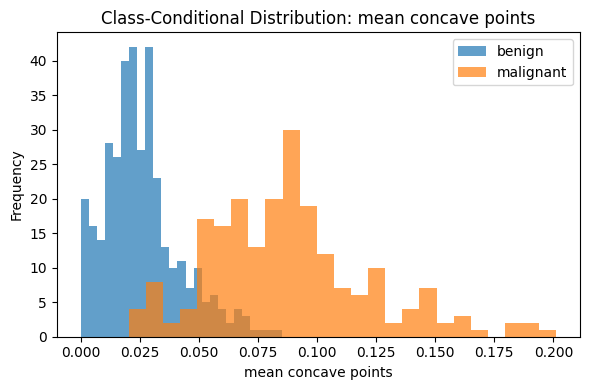

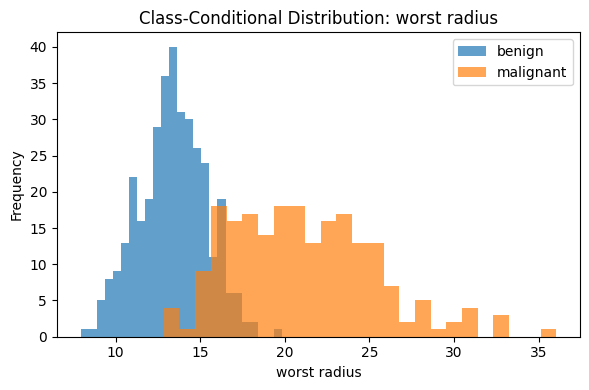

In [8]:
selected_features = top_correlations.index[:4].tolist()

for feature in selected_features:
    plt.figure(figsize=(6, 4))
    plt.hist(X.loc[y == 0, feature], bins=25, alpha=0.7, label="benign")
    plt.hist(X.loc[y == 1, feature], bins=25, alpha=0.7, label="malignant")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.title(f"Class-Conditional Distribution: {feature}")
    plt.legend()
    plt.tight_layout()
    plt.show()


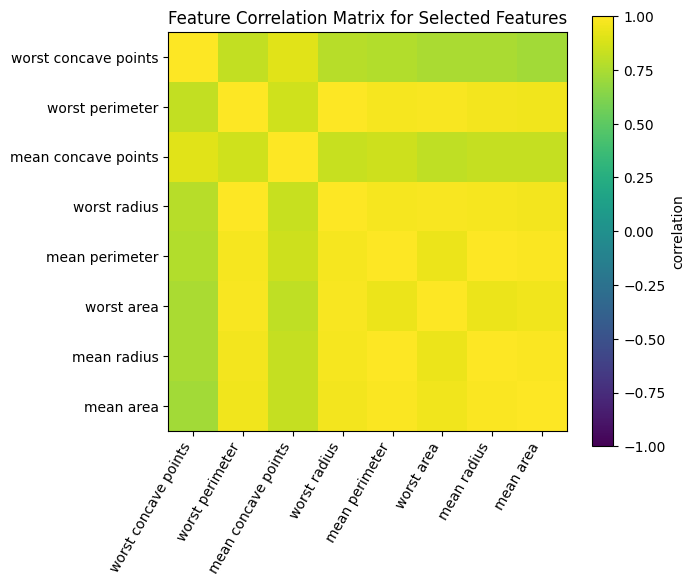

,worst concave points,worst perimeter,mean concave points,worst radius,mean perimeter,worst area,mean radius,mean area
worst concave points,1.0000,0.8163,0.9102,0.7874,0.7712,0.7474,0.7442,0.7220
worst perimeter,0.8163,1.0000,0.8559,0.9937,0.9704,0.9776,0.9651,0.9591
mean concave points,0.9102,0.8559,1.0000,0.8303,0.8510,0.8096,0.8225,0.8233
worst radius,0.7874,0.9937,0.8303,1.0000,0.9695,0.9840,0.9695,0.9627
mean perimeter,0.7712,0.9704,0.8510,0.9695,1.0000,0.9415,0.9979,0.9865
worst area,0.7474,0.9776,0.8096,0.9840,0.9415,1.0000,0.9411,0.9592
mean radius,0.7442,0.9651,0.8225,0.9695,0.9979,0.9411,1.0000,0.9874
mean area,0.7220,0.9591,0.8233,0.9627,0.9865,0.9592,0.9874,1.0000


In [9]:
# Inspect correlations among the most target-associated features.
corr_features = top_correlations.index[:8].tolist()
corr_matrix = X[corr_features].corr()

plt.figure(figsize=(7, 6))
plt.imshow(corr_matrix, vmin=-1, vmax=1)
plt.xticks(range(len(corr_features)), corr_features, rotation=60, ha="right")
plt.yticks(range(len(corr_features)), corr_features)
plt.colorbar(label="correlation")
plt.title("Feature Correlation Matrix for Selected Features")
plt.tight_layout()
plt.show()

corr_matrix


The correlation matrix shows that many features are strongly correlated. This is important because Gaussian Naive Bayes assumes conditional independence among features given the class.

In biomedical-style tabular data, this assumption is often unrealistic because measurements may be derived from related biological or imaging processes. Even so, Naive Bayes can still perform well as a simple probabilistic baseline.


## 5. Train/Test Split and Preprocessing

The data is split into training and test sets using stratification to preserve the class distribution.

Gaussian Naive Bayes estimates a mean and variance for each feature within each class. Standardization is not strictly required for Gaussian Naive Bayes, but it can improve numerical stability and keeps preprocessing consistent across examples.

The scaler is fit only on the training data and then applied to the test data to avoid data leakage.


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X.values,
    y.values,
    test_size=0.25,
    random_state=438,
    stratify=y.values,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set shape:", X_train_scaled.shape)
print("Test set shape:", X_test_scaled.shape)
print("Training class counts:", np.bincount(y_train))
print("Test class counts:", np.bincount(y_test))


Training set shape: (426, 30)
Test set shape: (143, 30)
Training class counts: [267 159]
Test class counts: [90 53]


## 6. Fit Custom Gaussian Naive Bayes

We fit the `GaussianNaiveBayes` model from the local `jiayi_ml` package.

The model estimates:

- Class prior probabilities
- Class-specific feature means
- Class-specific feature variances

Predictions are made by choosing the class with the largest posterior probability.


In [11]:
model = GaussianNaiveBayes(var_smoothing=1e-9)
model.fit(X_train_scaled, y_train)

print("Classes:", model.classes_)
print("Class priors:", model.class_prior_)
print("Theta shape:", model.theta_.shape)
print("Variance shape:", model.var_.shape)


Classes: [0 1]
Class priors: [0.62676056 0.37323944]
Theta shape: (2, 30)
Variance shape: (2, 30)


The class priors reflect the class distribution in the training set. The `theta_` matrix contains estimated feature means for each class, and the `var_` matrix contains estimated feature variances for each class.


## 7. Test-Set Evaluation

The default prediction rule assigns each sample to the class with the highest posterior probability.

We evaluate the model using:

- Accuracy
- Precision for malignant class
- Recall for malignant class
- F1 score for malignant class
- Confusion matrix


In [12]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision_malignant": precision_score(y_test, y_pred, pos_label=1),
    "recall_malignant": recall_score(y_test, y_pred, pos_label=1),
    "f1_malignant": f1_score(y_test, y_pred, pos_label=1),
}

metrics_df = pd.DataFrame(metrics, index=["Gaussian Naive Bayes"]).T
metrics_df


,Gaussian Naive Bayes
accuracy,0.9650
precision_malignant,0.9615
recall_malignant,0.9434
f1_malignant,0.9524


In [13]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
cm_df = pd.DataFrame(
    cm,
    index=["true benign", "true malignant"],
    columns=["predicted benign", "predicted malignant"],
)

cm_df


,predicted benign,predicted malignant
true benign,88,2
true malignant,3,50


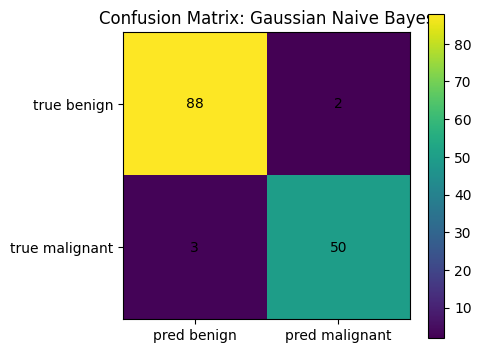

In [14]:
plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.xticks([0, 1], ["pred benign", "pred malignant"])
plt.yticks([0, 1], ["true benign", "true malignant"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.title("Confusion Matrix: Gaussian Naive Bayes")
plt.colorbar()
plt.tight_layout()
plt.show()


The confusion matrix separates correct predictions from two different error types:

- False positive: benign predicted as malignant.
- False negative: malignant predicted as benign.

In a screening-oriented health example, false negatives are particularly important because they represent missed malignant cases. This is why recall for the malignant class is important to inspect.


## 8. Probability Distribution and Confidence

Naive Bayes produces posterior class probabilities. These probabilities can be inspected to understand how confident the model is.

The following plot shows the predicted probability of malignancy for test samples, separated by true class.


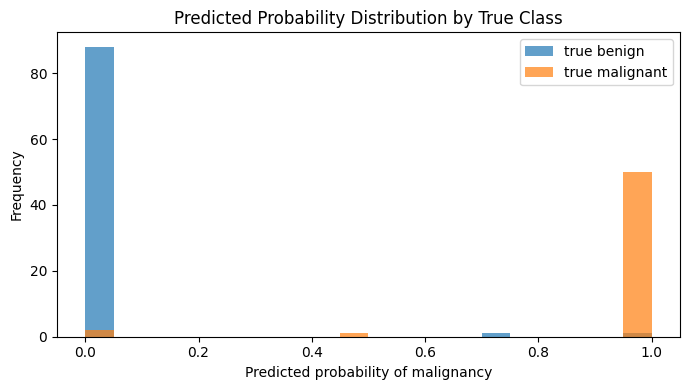

In [15]:
plt.figure(figsize=(7, 4))
plt.hist(y_proba[y_test == 0], bins=20, alpha=0.7, label="true benign")
plt.hist(y_proba[y_test == 1], bins=20, alpha=0.7, label="true malignant")
plt.xlabel("Predicted probability of malignancy")
plt.ylabel("Frequency")
plt.title("Predicted Probability Distribution by True Class")
plt.legend()
plt.tight_layout()
plt.show()


Ideally, true malignant cases should have high predicted probabilities, while true benign cases should have low predicted probabilities. Overlap between these distributions indicates uncertainty and potential classification errors.


## 9. Threshold Analysis

Although Naive Bayes predicts the class with the highest posterior probability by default, we can still adjust the threshold for predicting the malignant class.

Lowering the threshold usually increases recall but may increase false positives. Raising the threshold may increase precision but can increase false negatives.


In [16]:
def evaluate_threshold(threshold):
    predictions = np.where(y_proba >= threshold, 1, 0)
    cm_threshold = confusion_matrix(y_test, predictions, labels=[0, 1])
    
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, predictions),
        "precision": precision_score(y_test, predictions, pos_label=1),
        "recall": recall_score(y_test, predictions, pos_label=1),
        "f1": f1_score(y_test, predictions, pos_label=1),
        "false_positives": cm_threshold[0, 1],
        "false_negatives": cm_threshold[1, 0],
    }


thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
threshold_results = pd.DataFrame([evaluate_threshold(t) for t in thresholds])
threshold_results


,threshold,accuracy,precision,recall,f1,false_positives,false_negatives
0,0.1,0.972,0.9623,0.9623,0.9623,2,2
1,0.2,0.972,0.9623,0.9623,0.9623,2,2
2,0.3,0.972,0.9623,0.9623,0.9623,2,2
3,0.4,0.972,0.9623,0.9623,0.9623,2,2
4,0.5,0.965,0.9615,0.9434,0.9524,2,3
5,0.6,0.965,0.9615,0.9434,0.9524,2,3
6,0.7,0.965,0.9615,0.9434,0.9524,2,3
7,0.8,0.972,0.9804,0.9434,0.9615,1,3
8,0.9,0.972,0.9804,0.9434,0.9615,1,3


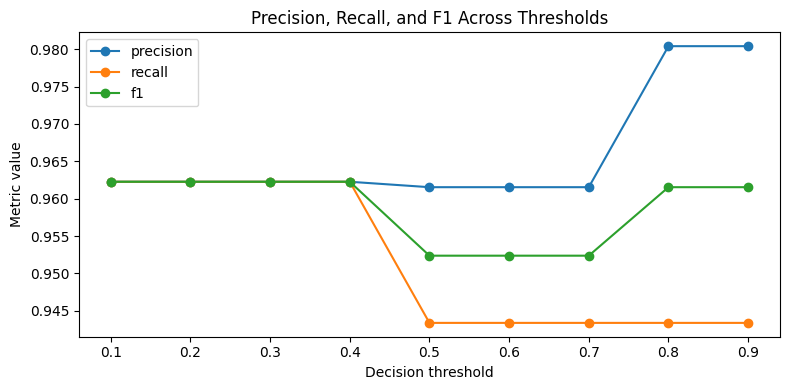

In [17]:
plt.figure(figsize=(8, 4))
plt.plot(threshold_results["threshold"], threshold_results["precision"], marker="o", label="precision")
plt.plot(threshold_results["threshold"], threshold_results["recall"], marker="o", label="recall")
plt.plot(threshold_results["threshold"], threshold_results["f1"], marker="o", label="f1")
plt.xlabel("Decision threshold")
plt.ylabel("Metric value")
plt.title("Precision, Recall, and F1 Across Thresholds")
plt.legend()
plt.tight_layout()
plt.show()


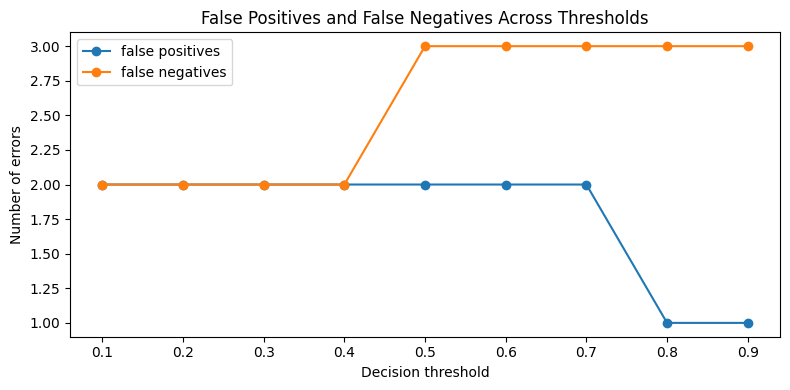

In [18]:
plt.figure(figsize=(8, 4))
plt.plot(
    threshold_results["threshold"],
    threshold_results["false_positives"],
    marker="o",
    label="false positives",
)
plt.plot(
    threshold_results["threshold"],
    threshold_results["false_negatives"],
    marker="o",
    label="false negatives",
)
plt.xlabel("Decision threshold")
plt.ylabel("Number of errors")
plt.title("False Positives and False Negatives Across Thresholds")
plt.legend()
plt.tight_layout()
plt.show()


Threshold analysis is important because the default threshold may not match the practical goal of the model.

If the goal is to reduce missed malignant cases, a lower threshold may be preferred because it tends to increase recall. However, this can increase false positives. The final threshold should depend on the relative cost of different error types.


## 10. Inspecting Class-Conditional Means

Gaussian Naive Bayes estimates a mean for each feature within each class.

The difference between class means can help identify features that separate the classes under the model. Because the data was standardized, these differences are on a comparable scale.


In [19]:
mean_difference = model.theta_[1] - model.theta_[0]

mean_diff_df = pd.DataFrame(
    {
        "feature": feature_names,
        "mean_malignant_minus_benign": mean_difference,
        "abs_difference": np.abs(mean_difference),
    }
).sort_values("abs_difference", ascending=False)

mean_diff_df.head(12)


,feature,mean_malignant_minus_benign,abs_difference
27,worst concave points,1.6106,1.6106
22,worst perimeter,1.6029,1.6029
20,worst radius,1.5927,1.5927
7,mean concave points,1.5736,1.5736
2,mean perimeter,1.5252,1.5252
23,worst area,1.5103,1.5103
0,mean radius,1.4999,1.4999
3,mean area,1.4598,1.4598
6,mean concavity,1.3806,1.3806
26,worst concavity,1.3204,1.3204


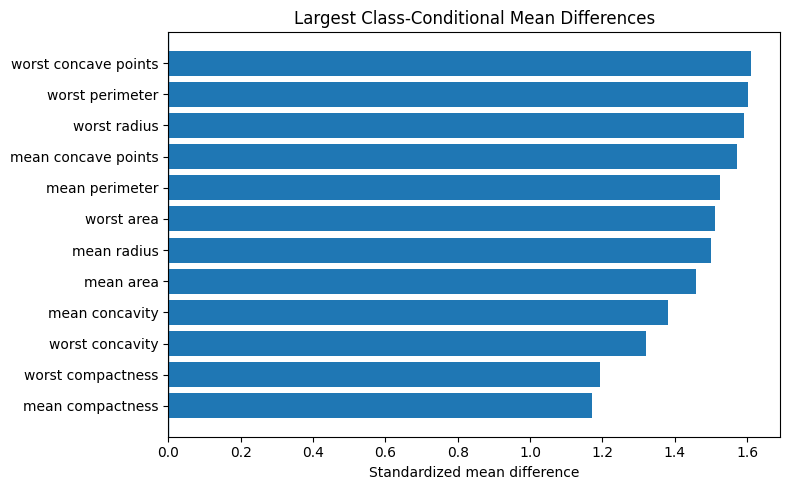

In [20]:
top_mean_diff = mean_diff_df.head(12).sort_values("mean_malignant_minus_benign")

plt.figure(figsize=(8, 5))
plt.barh(top_mean_diff["feature"], top_mean_diff["mean_malignant_minus_benign"])
plt.axvline(0, linewidth=1)
plt.xlabel("Standardized mean difference")
plt.title("Largest Class-Conditional Mean Differences")
plt.tight_layout()
plt.show()


The class-conditional mean differences show which standardized features have the largest average differences between malignant and benign samples.

This is useful for interpretation, but it is not causal evidence. It also does not fully account for correlations among features.


## 11. Interpretation

Gaussian Naive Bayes is attractive because it is simple, fast, and probabilistic. It estimates a class-specific Gaussian distribution for each feature and combines the evidence using Bayes' rule.

For this dataset, the model can perform well because several features show strong differences between benign and malignant samples.

However, the correlation analysis shows that the conditional independence assumption is likely imperfect. Many features are related measurements derived from similar image characteristics. This means the model's probability estimates should be interpreted cautiously.


## 12. Limitations

This analysis has several limitations:

1. The dataset is relatively small.
2. Gaussian Naive Bayes assumes class-conditional Gaussian feature distributions.
3. The model assumes features are conditionally independent given the class.
4. Many features in this dataset are correlated, which violates the independence assumption.
5. Probability estimates may be poorly calibrated.
6. The threshold should be chosen based on the intended use case.
7. This is an educational example, not a clinical diagnostic system.

A stronger analysis could include calibration curves, cross-validation, external validation, and comparison with other classifiers.


## 13. Conclusion

This notebook demonstrated Gaussian Naive Bayes using the custom `GaussianNaiveBayes` implementation from `jiayi_ml`.

Key takeaways:

- Gaussian Naive Bayes is a simple probabilistic classifier.
- It estimates class priors, class-specific feature means, and class-specific feature variances.
- Confusion matrices help identify false positives and false negatives.
- Threshold analysis changes the precision-recall trade-off.
- The independence assumption is important and often unrealistic in biomedical-style data.
- Even when assumptions are imperfect, Naive Bayes can be useful as a transparent baseline.
